# 雅可比与矩阵求导

第012单元。目标：逐层计算一个两层批次网络的完整梯度，并用显式雅可比、JVP、VJP与有限差分独立核验。先修011；运行前先完成lab.pdf的纸笔基准。

## 设置

CPU、NumPy、本地原创配置。重新启动内核后从头运行。下面只依赖本目录文件，不下载数据；输出写入notebook_outputs并可重复覆盖这三个输出文件。

In [1]:
from pathlib import Path
import numpy as np
from IPython.display import Image, display
from experiment import (load_config, forward, loss, gradients, parameter_jacobian,
                        jvp, vjp, flatten, central_gradients, run)
cfg, X, params, Y = load_config()
print("X", X.shape, "Y", Y.shape)
print({k: v.shape for k, v in params.items()})

X (2, 2) Y (2, 1)
{'W1': (2, 2), 'b1': (1, 2), 'W2': (2, 1), 'b2': (1, 1)}


## 第一步 先验算前向

两层之间逐元素平方。先算A，再算H，最后P；标签严格同shape。损失只除2N。

In [2]:
v = forward(X, params)
for name in ("A", "H", "P"):
    print(name, v[name])
print("loss", loss(X, params, Y))
assert loss(X, params, Y) == 29.140625

A [[ 2.   1.5]
 [-0.5  2.5]]
H [[4.   2.25]
 [0.25 6.25]]
P [[  0.  ]
 [-11.75]]
loss 29.140625


## 第二步 把上游权重逐层传回

梯度与对应参数同shape。对偏置沿样本轴求和，损失的平均系数不重复加入。

In [3]:
g = gradients(X, params, Y)
for name in ("P", "H", "A", "W2", "b2", "W1", "b1", "X"):
    print(name, g[name].shape, g[name])
np.testing.assert_array_equal(g["W1"], [[-7.375, -50.75], [1.375, 59.75]])

P (2, 1) [[-0.5  ]
 [-5.375]]
H (2, 2) [[-0.5    1.   ]
 [-5.375 10.75 ]]
A (2, 2) [[-2.     3.   ]
 [ 5.375 53.75 ]]
W2 (2, 1) [[ -3.34375]
 [-34.71875]]
b2 (1, 1) [[-5.875]]
W1 (2, 2) [[ -7.375 -50.75 ]
 [  1.375  59.75 ]]
b1 (1, 2) [[ 3.375 56.75 ]]
X (2, 2) [[ -5.       2.    ]
 [-48.375   56.4375]]


## 第三步 分开两份样本外积

外积生成权重shape的表；全批次共享参数梯度为贡献之和。

first
[[-2.  3.]
 [-4.  6.]]
second
[[ -5.375 -53.75 ]
 [  5.375  53.75 ]]


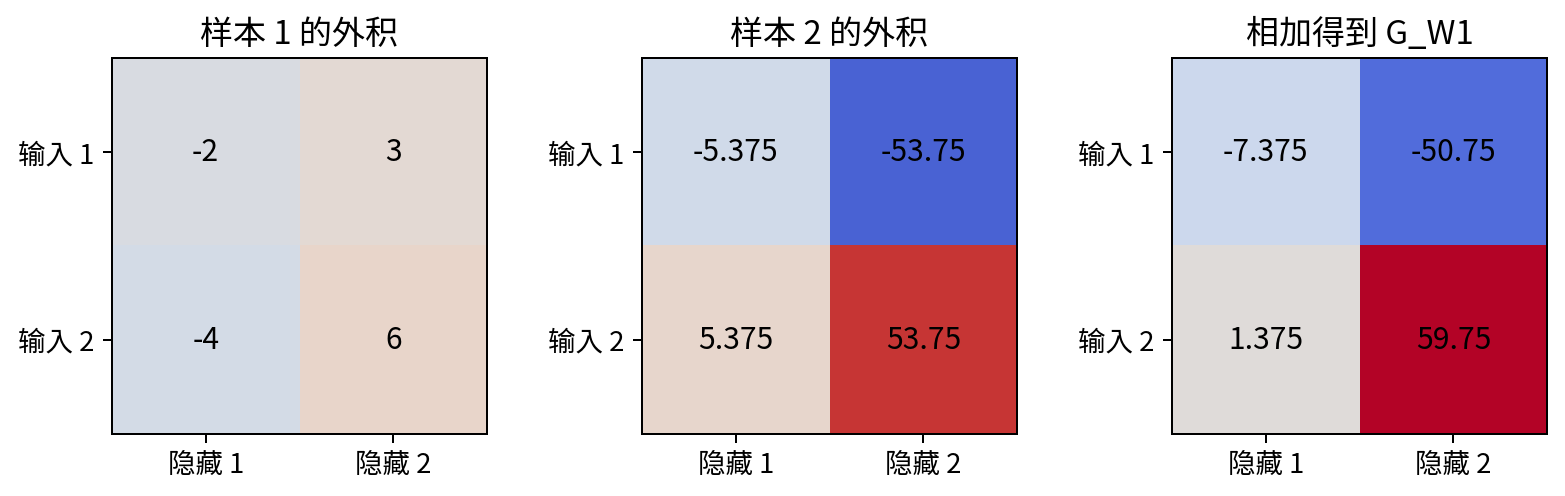

In [4]:
first = np.outer(X[0], g["A"][0])
second = np.outer(X[1], g["A"][1])
print("first", first, "second", second, sep="\n")
np.testing.assert_array_equal(first + second, g["W1"])
display(Image(filename="figures/04_contributions.png", width=760))

## 第四步 只在小例子建立完整雅可比

按W1、b1、W2、b2顺序，各矩阵按行展开。建表函数用逐索引解析式；VJP不调用这张表。

In [5]:
J = parameter_jacobian(X, params)
print(J.shape, J, sep="\n")
np.testing.assert_allclose(g["P"].ravel() @ J, flatten(g), atol=1e-12)

(2, 9)
[[  4.    -6.     8.   -12.     4.    -6.     4.     2.25   1.  ]
 [  1.    10.    -1.   -10.    -1.   -10.     0.25   6.25   1.  ]]


## 第五步 推一个参数方向

四组参数的所有方向元素均为0.1；X固定。输出约为(-0.075,-0.35)。

In [6]:
directions = {k: np.full_like(value, 0.1) for k, value in params.items()}
pushed = jvp(X, params, directions)
print(pushed)
np.testing.assert_allclose(pushed.ravel(), J @ flatten(directions), atol=1e-12)

[[-0.075]
 [-0.35 ]]


## 第六步 回传一个输出权重

这里权重为(1,2)，不是主损失的G_P。先前推再加权与先回传再配对得到同一个标量。

In [7]:
weights = np.array([[1.0], [2.0]])
pulled = vjp(X, params, weights)
left = float(np.sum(weights * pushed))
right = float(flatten(pulled) @ flatten(directions))
print(left, right)
assert abs(left-right) < 1e-12
assert abs(left+0.775) < 1e-12

-0.7750000000000005 -0.7749999999999997


## 第七步 用损失差分核对所有坐标

每次扰动都重算完整前向，比较全部9个参数和4个输入。差分近似不能证明一般可微性。

W1 6.175689293286268e-09
b1 2.0260060296095617e-09
W2 4.3962655738027934e-10
b2 2.668238963110525e-10
X 1.2162715279373515e-09


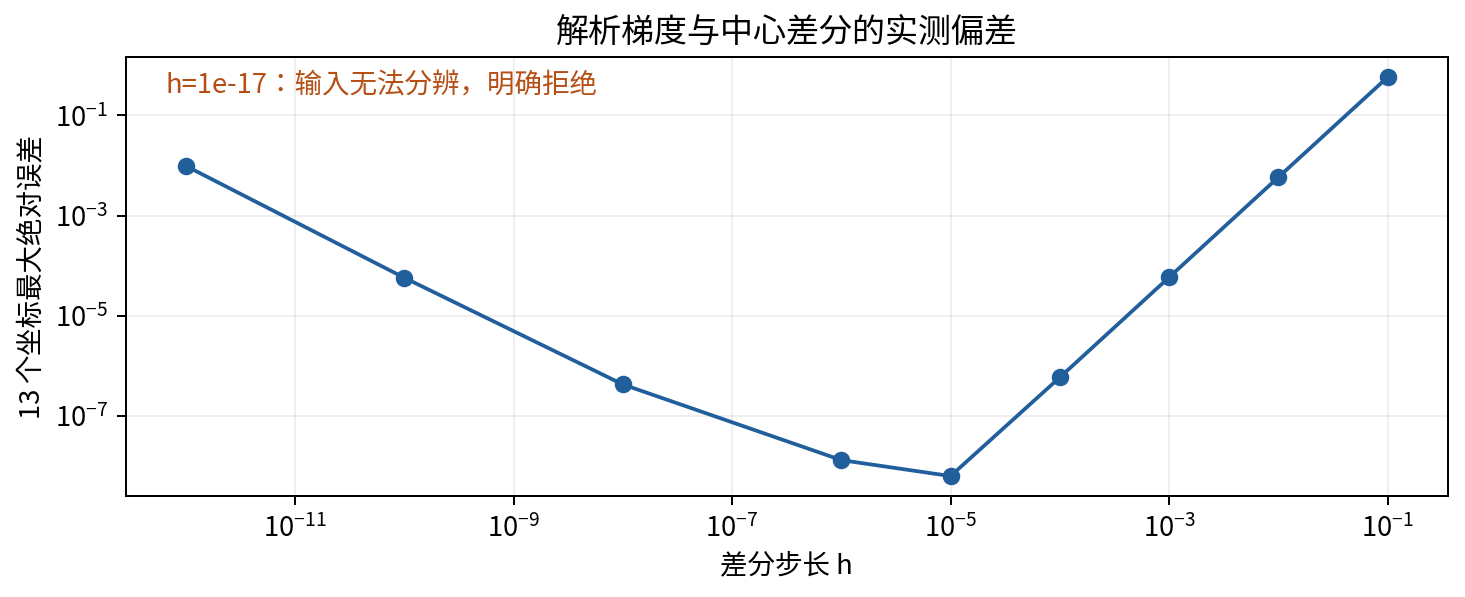

In [8]:
numeric = central_gradients(X, params, Y, 1e-5)
for name in numeric:
    error = float(np.max(np.abs(numeric[name] - g[name])))
    print(name, error)
    assert error < 2e-8
display(Image(filename="figures/07_difference.png", width=700))

## 第八步 故意制造三个同shape错误

shape正确仍可能数值错误。比较错误bias平均、漏平方导数、逐元素替代矩阵乘法。

In [9]:
wrong_bias = g["A"].mean(axis=0, keepdims=True)
wrong_activation = g["H"]
wrong_matmul = X.T * g["A"]
print("wrong bias", wrong_bias)
print("missing square rule", wrong_activation)
print("elementwise instead of matmul", wrong_matmul)
assert not np.array_equal(wrong_bias, g["b1"])
assert not np.array_equal(wrong_activation, g["A"])
assert not np.array_equal(wrong_matmul, g["W1"])

wrong bias [[ 1.6875 28.375 ]]
missing square rule [[-0.5    1.   ]
 [-5.375 10.75 ]]
elementwise instead of matmul [[-2.   -3.  ]
 [10.75 53.75]]


## 第九步 复制批次的结构检查

共享参数收集重复路径；每份输入坐标仍独立。

In [10]:
double_g = gradients(np.concatenate([X,X]), params, np.concatenate([Y,Y]))
for name in params:
    np.testing.assert_array_equal(double_g[name], g[name])
np.testing.assert_array_equal(double_g["X"], np.concatenate([g["X"]/2,g["X"]/2]))
print("参数梯度不变；每份输入梯度减半")

参数梯度不变；每份输入梯度减半


## 第十步 独立oracle和拒绝案例

Fraction逐样本、逐元素求和核对矩形维数；同时检查非法标签shape、布尔值、非有限值和无效差分步长。

In [11]:
from test_experiment import tests
checks = tests()
print(checks)
assert checks["status"] == "passed"

{'status': 'passed', 'groups': 7, 'details': ['complete exact hand calculation and explicit 2 by 9 Jacobian', '100 Fraction loop oracles with rectangular dimensions; explicit Jacobian JVP VJP identities', 'all nine parameters and four input coordinates independently differenced', 'batch duplication mean-loss invariance and permutation equivariance', '31 type shape range step rejection cases; original inputs unchanged', 'two full runs produce byte-identical three-file outputs', '6 document Python snippets execute in order'], 'fraction_fixtures': 100, 'rejected_cases': 31, 'python_snippets': 6}


## 第十一步 保存本次证据

报告与差分扫描使用相同核心函数；与脚本outputs的三个文件应逐字节一致。保留实际环境版本。

In [12]:
report = run(Path("notebook_outputs"))
assert report["loss"] == 29.140625
for name in ("results.json", "difference_scan.csv", "environment.json"):
    assert (Path("notebook_outputs")/name).read_bytes() == (Path("outputs")/name).read_bytes()
print("三个输出文件一致")

三个输出文件一致


## 下一步与边界

完整讨论见lecture.pdf，任务见lab.pdf，详解见answers.pdf。图的内存数值是公式计算，未分配巨型矩阵，也不报告运行峰值内存。该Notebook在新进程真实InProcessKernel顺序执行；未测试浏览器Jupyter界面、跨进程socket传输或新装Anaconda。有限测试覆盖所列样例，不保证全部浮点动态范围或训练效果。

来源：OpenStax多变量链式法则、JAX官方JVP/VJP文档、NumPy的matmul/sum/broadcasting；具体已检查链接见source-checks.json。